In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score,recall_score,f1_score,roc_auc_score,roc_curve
import nltk

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "spam.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mfaisalqureshi/spam-email",
  file_path,)

print("First 5 records:", df.head())

First 5 records:   Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
df["Category"]=df["Category"].map({"ham":0,"spam":1})
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# downloading stopwords
nltk.download("stopwords") 

stopwords downloaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PMLS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [30]:
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.str.lower()
    text = text.str.translate(str.maketrans("", "", string.punctuation))
    text = text.apply(
        lambda x: " ".join(
            word for word in x.split() if word not in stop_words
        )
    )
    return text

df["cleaned_text"] = clean_text(df["Message"])
df.tail()

,Category,Message,cleaned_text
5567,1,This is the 2nd time we have tried 2 contact u...,2nd time tried 2 contact u u £750 pound prize ...
5568,0,Will ü b going to esplanade fr home?,ü b going esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestions
5570,0,The guy did some bitching but I acted like i'd...,guy bitching acted like id interested buying s...
5571,0,Rofl. Its true to its name,rofl true name


In [33]:
X=df["cleaned_text"]
y=df["Category"]

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
# stratify to preserve ham/spam ratio in both sets

In [43]:
vectorizer=TfidfVectorizer( max_features=3000,ngram_range=(1,2))

X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf =vectorizer.transform(X_test)


In [44]:
nb=MultinomialNB()
nb.fit(X_train_tfidf,y_train)
y_pred=nb.predict(X_test_tfidf)
y_prob_nb = nb.predict_proba(X_test_tfidf)[:, 1]

In [45]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf,y_train)
y_pred_lr=lr.predict(X_test_tfidf)
y_prob_lr=lr.predict_proba(X_test_tfidf)[:, 1]

In [46]:
def evaluate(y_true,y_pred,y_proba):
    return {
        "precision":precision_score(y_test,y_pred),
        "recall":recall_score(y_test,y_pred),
        "f1": f1_score(y_true,y_pred),
        "roc_auc": roc_auc_score(y_true,y_proba)
    }

In [49]:
nb_metrics=evaluate(y_test,y_pred,y_prob_nb)
lr_metrics=evaluate(y_test,y_pred_lr,y_prob_lr)
print(nb_metrics,"\n",lr_metrics)

{'precision': 1.0, 'recall': 0.7785234899328859, 'f1': 0.8754716981132076, 'roc_auc': 0.9852293412258396} 
 {'precision': 1.0, 'recall': 0.7718120805369127, 'f1': 0.8712121212121212, 'roc_auc': 0.9849861742187391}


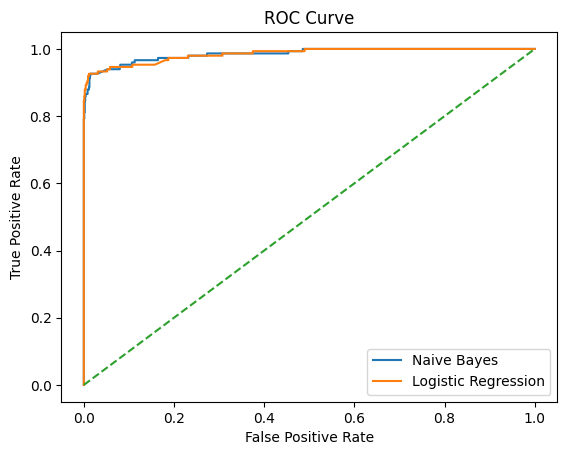

In [50]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [68]:
def clean_prediction_text(text):
    text=text.lower()
    text=text.translate(str.maketrans("", "", string.punctuation))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)
def predict_message(text):
    cleaned=clean_prediction_text(text)
    vector=vectorizer.transform([cleaned])
    prob=lr.predict_proba(vector)[0][1]
    label="spam" if prob>=0.5 else "ham"
    return label,prob

predict_message("You are selected for a cash reward. Reply YES to receive.")

('spam', 0.6433922676232824)